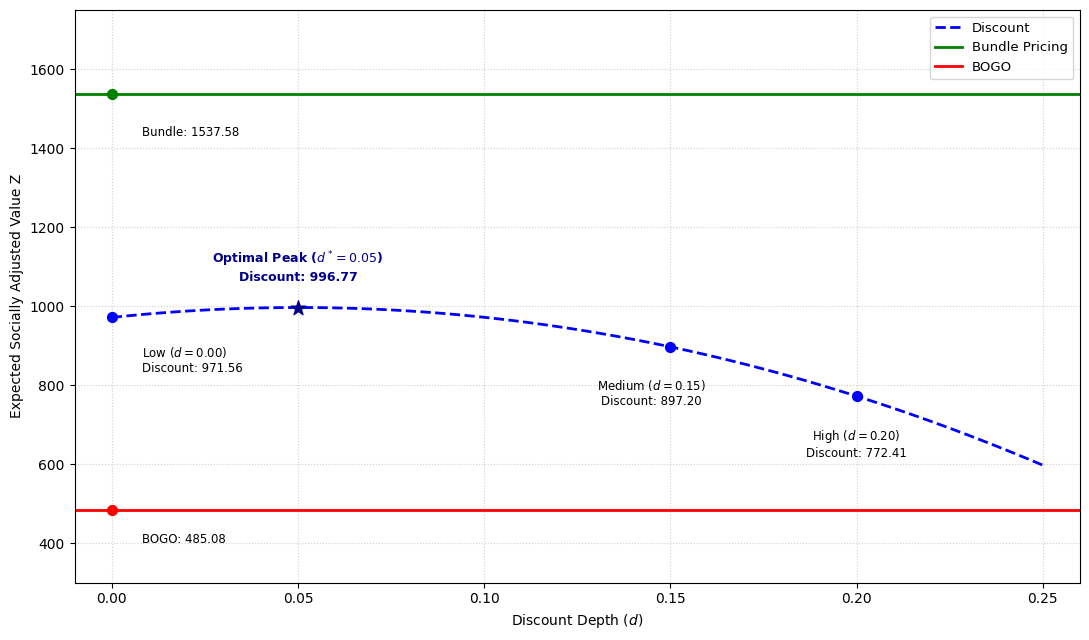

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


a, b, t, P, C, Cw, Q = 200, 1.0, 3, 100, 40, 2, 200
sigma = 20
delta_val = 2.0
lmbda_val = 2.0

np.random.seed(42)
epsilon = np.random.normal(0, sigma, 10000)


D_bundle = (1 + 0.10) * (a - b * 75 - delta_val * t)
Y_bundle = np.minimum(Q, np.maximum(D_bundle + epsilon, 0))
Z_bundle_base = np.mean(
    75 * Y_bundle - C * Q - (Cw + lmbda_val) * (Q - Y_bundle)
)


D_bogo = (1 + 0.20) * (a - b * 50 - delta_val * t)
Y_bogo = np.minimum(Q, np.maximum(D_bogo + epsilon, 0))
Z_bogo_base = np.mean(50 * Y_bogo - C * Q - (Cw + lmbda_val) * (Q - Y_bogo))


d_range = np.linspace(0.00, 0.25, 101)
z_discount_list = []

for d in d_range:
  Ps = P * (1 - d)
  D_disc = (1 + 0.00) * (a - b * Ps - delta_val * t)
  Y_disc = np.minimum(Q, np.maximum(D_disc + epsilon, 0))
  Z_disc = np.mean(Ps * Y_disc - C * Q - (Cw + lmbda_val) * (Q - Y_disc))
  z_discount_list.append(Z_disc)

df_disc = pd.DataFrame({'d': d_range, 'Z_Discount': z_discount_list})


opt_idx = df_disc['Z_Discount'].idxmax()
opt_d = df_disc.loc[opt_idx, 'd']
opt_z = df_disc.loc[opt_idx, 'Z_Discount']


plt.figure(figsize=(11, 6.5))


plt.plot(
    df_disc['d'],
    df_disc['Z_Discount'],
    label='Discount',
    color='blue',
    linestyle='--',
    linewidth=2,
)
plt.axhline(
    y=Z_bundle_base, label='Bundle Pricing', color='green', linestyle='-', linewidth=2
)
plt.axhline(
    y=Z_bogo_base, label='BOGO', color='red', linestyle='-', linewidth=2
)


plt.scatter([0.00], [Z_bundle_base], color='green', s=50, zorder=5)
plt.text(
    0.008,
    Z_bundle_base - 80,
    f'Bundle: {Z_bundle_base:.2f}',
    fontsize=8.5,
    ha='left',
    va='top',
)

plt.scatter([0.00], [Z_bogo_base], color='red', s=50, zorder=5)
plt.text(
    0.008,
    Z_bogo_base - 60,
    f'BOGO: {Z_bogo_base:.2f}',
    fontsize=8.5,
    ha='left',
    va='top',
)


idx_low = (df_disc['d'] - 0.00).abs().idxmin()
z_low = df_disc.loc[idx_low, 'Z_Discount']
plt.scatter([0.00], [z_low], color='blue', s=50, zorder=5)
plt.text(
    0.008,
    z_low - 70,
    f'Low ($d=0.00$)\nDiscount: {z_low:.2f}',
    fontsize=8.5,
    ha='left',
    va='top',
)


plt.scatter([opt_d], [opt_z], color='darkblue', marker='*', s=120, zorder=6)
plt.text(
    opt_d,
    opt_z + 60,
    f'Optimal Peak ($d^*={opt_d:.2f}$)\nDiscount: {opt_z:.2f}',
    fontsize=9,
    fontweight='bold',
    color='darkblue',
    ha='center',
    va='bottom',
)


idx_med = (df_disc['d'] - 0.15).abs().idxmin()
d_med = df_disc.loc[idx_med, 'd']
z_med = df_disc.loc[idx_med, 'Z_Discount']
plt.scatter([d_med], [z_med], color='blue', s=50, zorder=5)
plt.text(
    d_med - 0.005,
    z_med - 80,
    f'Medium ($d=0.15$)\nDiscount: {z_med:.2f}',
    fontsize=8.5,
    ha='center',
    va='top',
)


idx_high = (df_disc['d'] - 0.20).abs().idxmin()
d_high = df_disc.loc[idx_high, 'd']
z_high = df_disc.loc[idx_high, 'Z_Discount']
plt.scatter([d_high], [z_high], color='blue', s=50, zorder=5)
plt.text(
    d_high,
    z_high - 80,
    f'High ($d=0.20$)\nDiscount: {z_high:.2f}',
    fontsize=8.5,
    ha='center',
    va='top',
)



plt.xlabel('Discount Depth ($d$)', fontsize=10)
plt.ylabel('Expected Socially Adjusted Value Z', fontsize=10)
plt.xlim(-0.01, 0.26)
plt.ylim(300, 1750)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=9.5)
plt.tight_layout()

plt.show()